# Treinamento do MLP

Vamos utilizar a implementação do [Scikit Learn](https://scikit-learn.org/stable/index.html) do [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

In [1]:
!pip install -r requirements.txt

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import scipy.io as sio
from nptdms import TdmsFile
from scipy.fft import fft, rfft, rfftfreq
import os
import re

In [3]:
acoustic_path = "dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/acoustic"
vibration_path = "dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/vibration"
current_temp_path = "dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/current,temp"

acoustic_files = [f for f in Path(acoustic_path).iterdir() if f.is_file()]
vibration_files = [f for f in Path(vibration_path).iterdir() if f.is_file()]
current_temp_files = [f for f in Path(current_temp_path).iterdir() if f.is_file()]

In [4]:
for file in vibration_files:
    print(file)

dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/vibration/4Nm_Unbalance_2239mg.mat
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/vibration/4Nm_Misalign_01.mat
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/vibration/2Nm_Unbalalnce_0583mg.mat
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/vibration/2Nm_Misalign_03.mat
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/vibration/2Nm_Misalign_05.mat
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/vibration/0

In [5]:
for file in current_temp_files:
    print(file)

dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/current,temp/2Nm_BPFI_10.tdms
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/current,temp/0Nm_BPFO_03.tdms
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/current,temp/2Nm_Misalign_05.tdms
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/current,temp/2Nm_Normal.tdms
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/current,temp/0Nm_BPFI_03.tdms
dataset/Vibration, Acoustic, Temperature, and Motor Current Dataset of Rotating Machine Under Varying Load Conditions for Fault Diagnosis/current,temp/4Nm_No

## Extração de características — sem juntar as tabelas inteiras

O `merge_asof` sobre as tabelas completas não cabe na memória. São ~115 M de linhas
de cada lado (25,6 kHz × ~300 s × 45 ensaios):

| etapa | memória |
|---|---|
| `current_temp_combined_df` (8 colunas) | ~7,4 GB |
| `df_vibration` (7 colunas) | ~6,4 GB |
| os dois `sort_values()` (cópias completas) | ~13,8 GB |
| resultado do `merge_asof` (11 colunas) | ~10 GB |
| **pico** | **~38 GB** (a máquina tem 31 GB) |

Só que o join global nunca é necessário: tudo o que vem depois dele
(`groupby("file_name")` → FFT por janela) trabalha **um ensaio por vez**. E, dentro
de um mesmo ensaio, as duas fontes começam no mesmo `t0` e são amostradas a
25,6 kHz — ou seja, o `merge_asof(direction="nearest")` é, na prática, um
alinhamento posicional amostra a amostra.

O fluxo abaixo processa um par de arquivos por vez, extrai o espectro e descarta o
sinal bruto. Pico de **~1,6 GB** e ~10 s para os 45 ensaios.


In [6]:
# Pareia vibração (.mat) com corrente/temperatura (.tdms) — só metadados, nada é lido.
# Os .mat gravam "Unbalalnce" onde os .tdms gravam "Unbalance"; sem normalizar essa
# diferença o `by="file_name"` do merge não casa e 5 dos 45 ensaios somem do dataset.
def canonical(stem: str) -> str:
    return stem.replace("Unbalalnce", "Unbalance")


def error_type(name: str) -> str:
    if "BPFI" in name or "BPFO" in name:
        return "Bearing"
    elif "Unbalance" in name:
        return "Unbalance"
    elif "Misalign" in name:
        return "Misalign"
    elif "Normal" in name:
        return "None"
    raise ValueError(f"Tipo de falha desconhecido: {name}")


vib_by_key = {canonical(f.stem): f for f in vibration_files}
cur_by_key = {canonical(f.stem): f for f in current_temp_files}

keys = sorted(vib_by_key.keys() & cur_by_key.keys())
labels = {k: error_type(k) for k in keys}

print(f"{len(keys)} ensaios pareados | sem par: {sorted(vib_by_key.keys() ^ cur_by_key.keys())}")
pd.Series(labels).value_counts()

45 ensaios pareados | sem par: []


Bearing      18
Unbalance    15
Misalign      9
None          3
Name: count, dtype: int64

In [7]:
FS = 25600.0        # Nominal sampling frequency (Hz), both sources
WINDOW = 64         # FFT window size
STEP = WINDOW       # No overlap (change to WINDOW//2 for 50% overlap)

VIB_CHANNELS = [
    "x_direction_housing_A",
    "y_direction_housing_A",
    "x_direction_housing_B",
    "y_direction_housing_B",
]
TDMS_CHANNELS = {
    "cDAQ9185-1F486B5Mod1/ai0": "Temperature_housing_A",
    "cDAQ9185-1F486B5Mod1/ai1": "Temperature_housing_B",
    "cDAQ9185-1F486B5Mod2/ai0": "U-phase",
    "cDAQ9185-1F486B5Mod2/ai2": "V-phase",
    "cDAQ9185-1F486B5Mod2/ai3": "W-phase",
}
TDMS_BY_NAME = {v: k for k, v in TDMS_CHANNELS.items()}
PHASES = ["U-phase", "V-phase", "W-phase"]


def load_vibration(mat_path):
    """(n, 4) float64 + intervalo de amostragem, direto do .mat."""
    signal_struct = sio.loadmat(str(mat_path))["Signal"][0, 0]
    raw_data = signal_struct["y_values"][0, 0][0]

    dt = 1.0 / FS
    if "x_values" in (signal_struct.dtype.names or ()) and signal_struct["x_values"].size:
        x_struct = signal_struct["x_values"][0, 0]
        if "increment" in (x_struct.dtype.names or ()):
            dt = float(np.ravel(x_struct["increment"])[0])

    if raw_data.ndim == 2 and raw_data.shape[1] == 5:  # coluna de tempo à frente
        raw_data = raw_data[:, 1:]
    return np.ascontiguousarray(raw_data), dt


def load_current_temp(tdms_path, wanted):
    """(n, len(wanted)) float64 + intervalo de amostragem + t0 absoluto.

    `TdmsFile.open` mantém o arquivo em disco e lê canal a canal, em vez de
    carregar o arquivo inteiro na memória como `TdmsFile.read` faz.
    """
    with TdmsFile.open(str(tdms_path)) as tdms_file:
        log_group = tdms_file["Log"]
        props = log_group.channels()[0].properties
        dt = float(props["wf_increment"])
        t0 = pd.Timestamp(props["wf_start_time"])
        columns = [np.asarray(log_group[TDMS_BY_NAME[name]][:]) for name in wanted]
    return np.column_stack(columns), dt, t0


def align_to(x, dt_src, n_dst, dt_dst):
    """Reamostra `x` no grid de `n_dst` pontos espaçados de `dt_dst`, pegando o
    vizinho mais próximo — o equivalente vetorizado de
    `pd.merge_asof(..., direction="nearest")` para séries uniformemente amostradas.
    """
    idx = np.rint(np.arange(n_dst) * (dt_dst / dt_src)).astype(np.int64)
    np.clip(idx, 0, len(x) - 1, out=idx)
    return x[idx]


def window_spectra(x, window=WINDOW, step=STEP):
    """|rfft| de todas as janelas de `x` de uma vez: (n_janelas, window//2 + 1) float32.

    Substitui o laço `for start in range(...)` — mesmo resultado, uma chamada de FFT.
    """
    n_win = 1 + (len(x) - window) // step if len(x) >= window else 0
    if n_win == 0:
        return np.empty((0, window // 2 + 1), dtype=np.float32)

    if step == window:
        frames = x[: n_win * window].reshape(n_win, window)
    else:
        frames = np.lib.stride_tricks.sliding_window_view(x, window)[::step][:n_win]

    frames = frames - frames.mean(axis=1, keepdims=True)
    return np.abs(rfft(frames, axis=1)).astype(np.float32)


freqs = rfftfreq(WINDOW, d=1 / FS)
print(f"{len(freqs)} bins de frequência, resolução {freqs[1]:.1f} Hz")

33 bins de frequência, resolução 400.0 Hz


In [8]:
# Nos 9 ensaios BPFO os canais V-phase e W-phase foram gravados vazios (0 amostras).
# Mantê-los viraria vazamento de rótulo: "V-phase toda zerada" identificaria a classe
# Bearing sozinha. Então usamos só as fases presentes em TODOS os ensaios.
empty_channels = {}
for key in keys:
    with TdmsFile.open(str(cur_by_key[key])) as tdms_file:
        log_group = tdms_file["Log"]
        for name in PHASES:
            if len(log_group[TDMS_BY_NAME[name]]) == 0:
                empty_channels.setdefault(name, []).append(key)

for name, affected in empty_channels.items():
    print(f"{name}: vazio em {len(affected)} ensaios -> {affected}")

PHASES_USED = [name for name in PHASES if name not in empty_channels]
signals = VIB_CHANNELS + PHASES_USED
print(f"\nsinais usados ({len(signals)}): {signals}")

V-phase: vazio em 9 ensaios -> ['0Nm_BPFO_03', '0Nm_BPFO_10', '0Nm_BPFO_30', '2Nm_BPFO_03', '2Nm_BPFO_10', '2Nm_BPFO_30', '4Nm_BPFO_03', '4Nm_BPFO_10', '4Nm_BPFO_30']
W-phase: vazio em 9 ensaios -> ['0Nm_BPFO_03', '0Nm_BPFO_10', '0Nm_BPFO_30', '2Nm_BPFO_03', '2Nm_BPFO_10', '2Nm_BPFO_30', '4Nm_BPFO_03', '4Nm_BPFO_10', '4Nm_BPFO_30']

sinais usados (5): ['x_direction_housing_A', 'y_direction_housing_A', 'x_direction_housing_B', 'y_direction_housing_B', 'U-phase']


In [9]:
def join_one_file(key: str) -> pd.DataFrame:
    """Vibração + corrente de UM ensaio, alinhadas amostra a amostra.

    É o mesmo resultado do `merge_asof(direction="nearest", tolerance=1s)` do fluxo
    antigo, restrito a um ensaio: ~0,5 GB em vez dos ~38 GB do join global.

    As duas fontes começam no mesmo t0 e correm a 25,6 kHz; o `wf_increment` do TDMS
    (3,905e-05) é a versão arredondada do incremento do .mat (3,90625e-05), então
    `align_to` só corrige essa deriva de 0,03 %.
    """
    vibration_data, dt_vib = load_vibration(vib_by_key[key])
    current_data, dt_cur, t0 = load_current_temp(cur_by_key[key], PHASES_USED)
    n = len(vibration_data)

    df = pd.DataFrame(vibration_data, columns=VIB_CHANNELS)
    for j, name in enumerate(PHASES_USED):
        df[name] = align_to(current_data[:, j], dt_cur, n, dt_vib)

    df["Timestamp"] = t0 + pd.to_timedelta(np.arange(n) * dt_vib, unit="s")
    df["file_name"] = key
    df["Error_Type"] = labels[key]
    return df


# Espiada em um ensaio — o `final_df` do fluxo antigo, mas de um arquivo só.
sample_df = join_one_file(keys[0])
print(keys[0], sample_df.shape, f"{sample_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
sample_df.head()

0Nm_BPFI_03 (1536000, 8) 0.25 GB


,x_direction_housing_A,y_direction_housing_A,x_direction_housing_B,y_direction_housing_B,U-phase,Timestamp,file_name,Error_Type
0,-8.947968,14.536224,-1.054167,0.969664,1.894377,2021-06-28 11:02:43.489671000,0Nm_BPFI_03,Bearing
1,2.321366,-2.065806,-1.840423,3.046795,2.128889,2021-06-28 11:02:43.489710062,0Nm_BPFI_03,Bearing
2,0.273554,2.071666,-0.860117,2.146393,2.373001,2021-06-28 11:02:43.489749125,0Nm_BPFI_03,Bearing
3,-7.890409,15.446308,-0.465193,1.381279,2.087747,2021-06-28 11:02:43.489788188,0Nm_BPFI_03,Bearing
4,-1.295177,-0.780089,0.003352,-0.305207,2.393572,2021-06-28 11:02:43.489827250,0Nm_BPFI_03,Bearing


In [10]:
del sample_df  # libera antes do laço principal

In [11]:
# Laço principal: um par de arquivos por vez. O sinal bruto é descartado assim que
# o espectro sai, então o pico de memória é o de UM ensaio (~1,6 GB), não o do dataset.
fft_results = {}
vib_peak = np.zeros(len(VIB_CHANNELS))  # maior |amostra| por canal, p/ dimensionar o int24

for key in keys:
    vibration_data, dt_vib = load_vibration(vib_by_key[key])
    n = len(vibration_data)
    vib_peak = np.maximum(vib_peak, np.abs(vibration_data).max(axis=0))
    spectra = {
        name: window_spectra(vibration_data[:, j])
        for j, name in enumerate(VIB_CHANNELS)
    }
    del vibration_data

    current_data, dt_cur, _ = load_current_temp(cur_by_key[key], PHASES_USED)
    for j, name in enumerate(PHASES_USED):
        spectra[name] = window_spectra(align_to(current_data[:, j], dt_cur, n, dt_vib))
    del current_data

    # Trunca no menor número de janelas para as duas fontes ficarem alinhadas.
    n_win = min(spectrum.shape[0] for spectrum in spectra.values())
    fft_results[key] = {name: spectrum[:n_win] for name, spectrum in spectra.items()}

print("FFT completed.")

In [12]:
# fft_results[ensaio][sinal] -> array (n_janelas, n_bins) float32
total_windows = sum(d[signals[0]].shape[0] for d in fft_results.values())
total_bytes = sum(s.nbytes for d in fft_results.values() for s in d.values())
print(f"{len(fft_results)} ensaios, {total_windows:,} janelas, {total_bytes / 1e9:.2f} GB")
fft_results[keys[0]][signals[0]].shape

45 ensaios, 1,800,000 janelas, 1.19 GB


(24000, 33)

In [13]:
fft_results.keys()

dict_keys(['0Nm_BPFI_03', '0Nm_BPFI_10', '0Nm_BPFI_30', '0Nm_BPFO_03', '0Nm_BPFO_10', '0Nm_BPFO_30', '0Nm_Misalign_01', '0Nm_Misalign_03', '0Nm_Misalign_05', '0Nm_Normal', '0Nm_Unbalance_0583mg', '0Nm_Unbalance_1169mg', '0Nm_Unbalance_1751mg', '0Nm_Unbalance_2239mg', '0Nm_Unbalance_3318mg', '2Nm_BPFI_03', '2Nm_BPFI_10', '2Nm_BPFI_30', '2Nm_BPFO_03', '2Nm_BPFO_10', '2Nm_BPFO_30', '2Nm_Misalign_01', '2Nm_Misalign_03', '2Nm_Misalign_05', '2Nm_Normal', '2Nm_Unbalance_0583mg', '2Nm_Unbalance_1169mg', '2Nm_Unbalance_1751mg', '2Nm_Unbalance_2239mg', '2Nm_Unbalance_3318mg', '4Nm_BPFI_03', '4Nm_BPFI_10', '4Nm_BPFI_30', '4Nm_BPFO_03', '4Nm_BPFO_10', '4Nm_BPFO_30', '4Nm_Misalign_01', '4Nm_Misalign_03', '4Nm_Misalign_05', '4Nm_Normal', '4Nm_Unbalance_0583mg', '4Nm_Unbalance_1169mg', '4Nm_Unbalance_1751mg', '4Nm_Unbalance_2239mg', '4Nm_Unbalance_3318mg'])

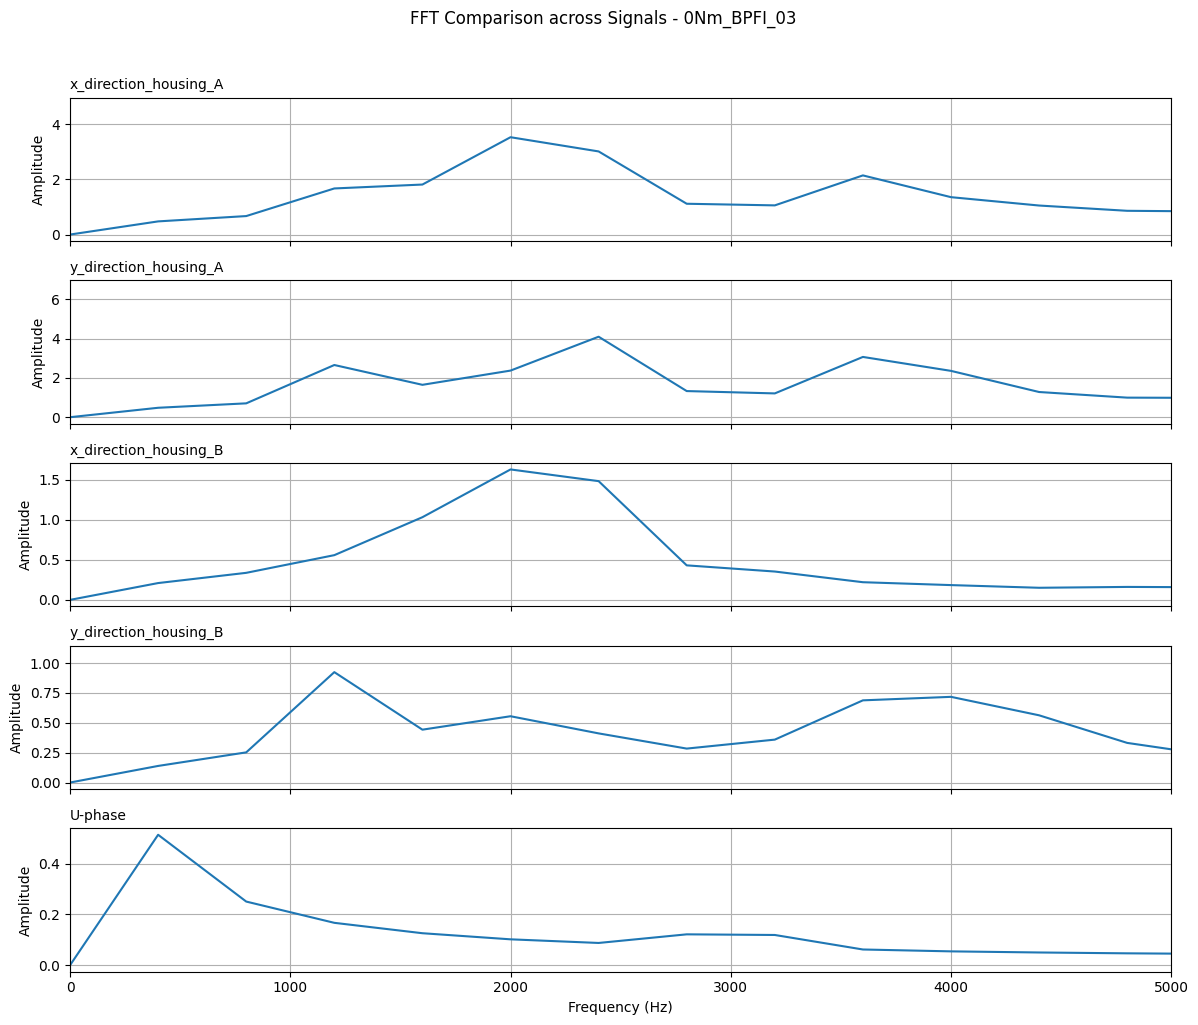

In [14]:
target_file = list(fft_results.keys())[0]
signals_to_plot = list(fft_results[target_file].keys())

fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(12, 2 * len(signals_to_plot)), sharex=True)

for ax, signal in zip(axes, signals_to_plot):
    windows = fft_results[target_file][signal]   # (n_janelas, n_bins)
    if len(windows):
        avg_amplitude = windows.mean(axis=0) * (2 / WINDOW)

        ax.plot(freqs, avg_amplitude, color='tab:blue')
        ax.set_ylabel("Amplitude")
        ax.set_title(signal, fontsize=10, loc='left')
        ax.grid(True)

axes[-1].set_xlabel("Frequency (Hz)")
plt.xlim(0, 5000)
plt.suptitle(f"FFT Comparison across Signals - {target_file}", y=1.02)
plt.tight_layout()
plt.show()

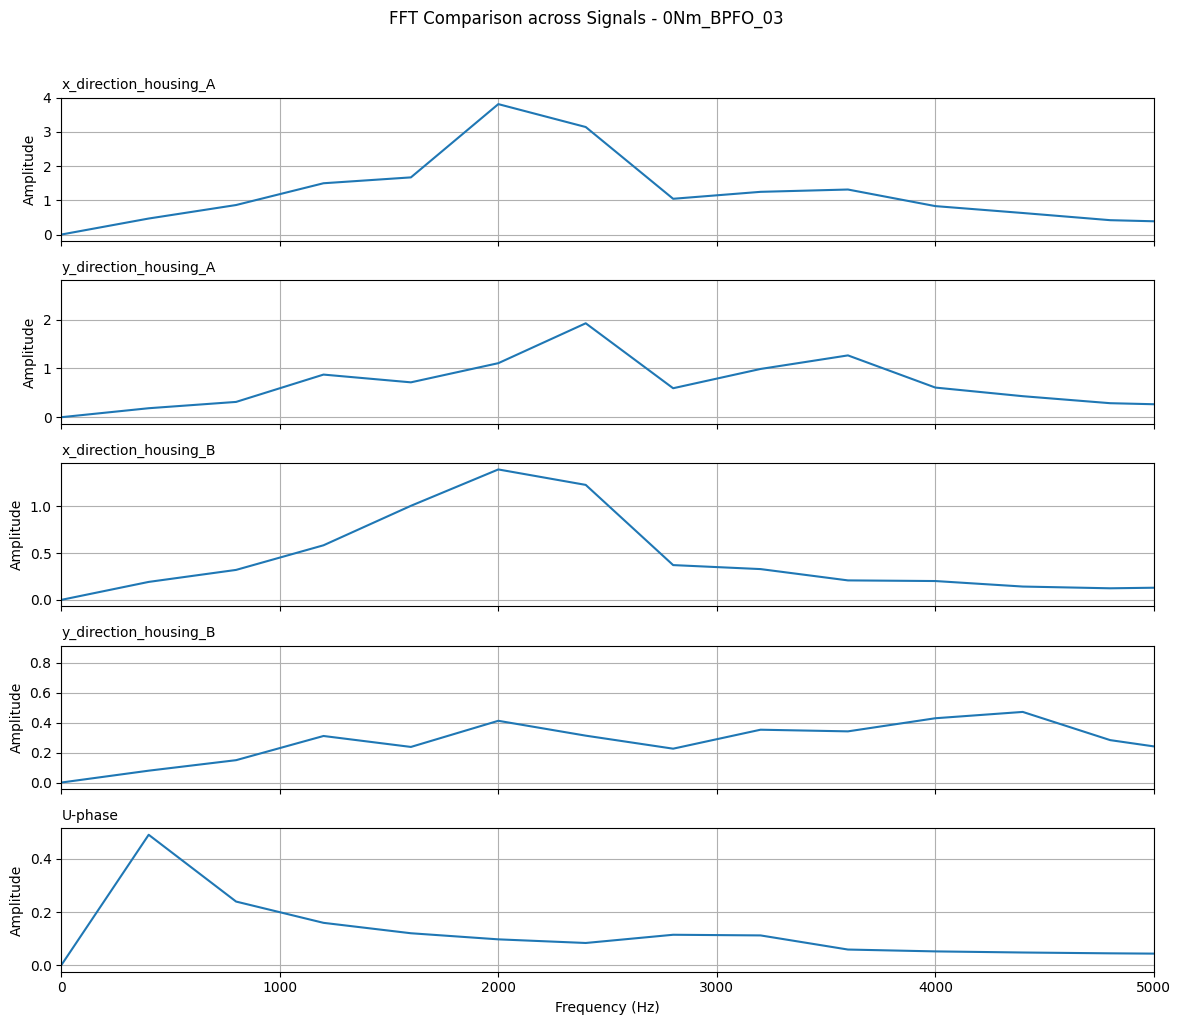

In [15]:
target_file = list(fft_results.keys())[3]
signals_to_plot = list(fft_results[target_file].keys())

fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(12, 2 * len(signals_to_plot)), sharex=True)

for ax, signal in zip(axes, signals_to_plot):
    windows = fft_results[target_file][signal]
    if len(windows):
        avg_amplitude = windows.mean(axis=0) * (2 / WINDOW)

        ax.plot(freqs, avg_amplitude, color='tab:blue')
        ax.set_ylabel("Amplitude")
        ax.set_title(signal, fontsize=10, loc='left')
        ax.grid(True)

axes[-1].set_xlabel("Frequency (Hz)")
plt.xlim(0, 5000)
plt.suptitle(f"FFT Comparison across Signals - {target_file}", y=1.02)
plt.tight_layout()
plt.show()

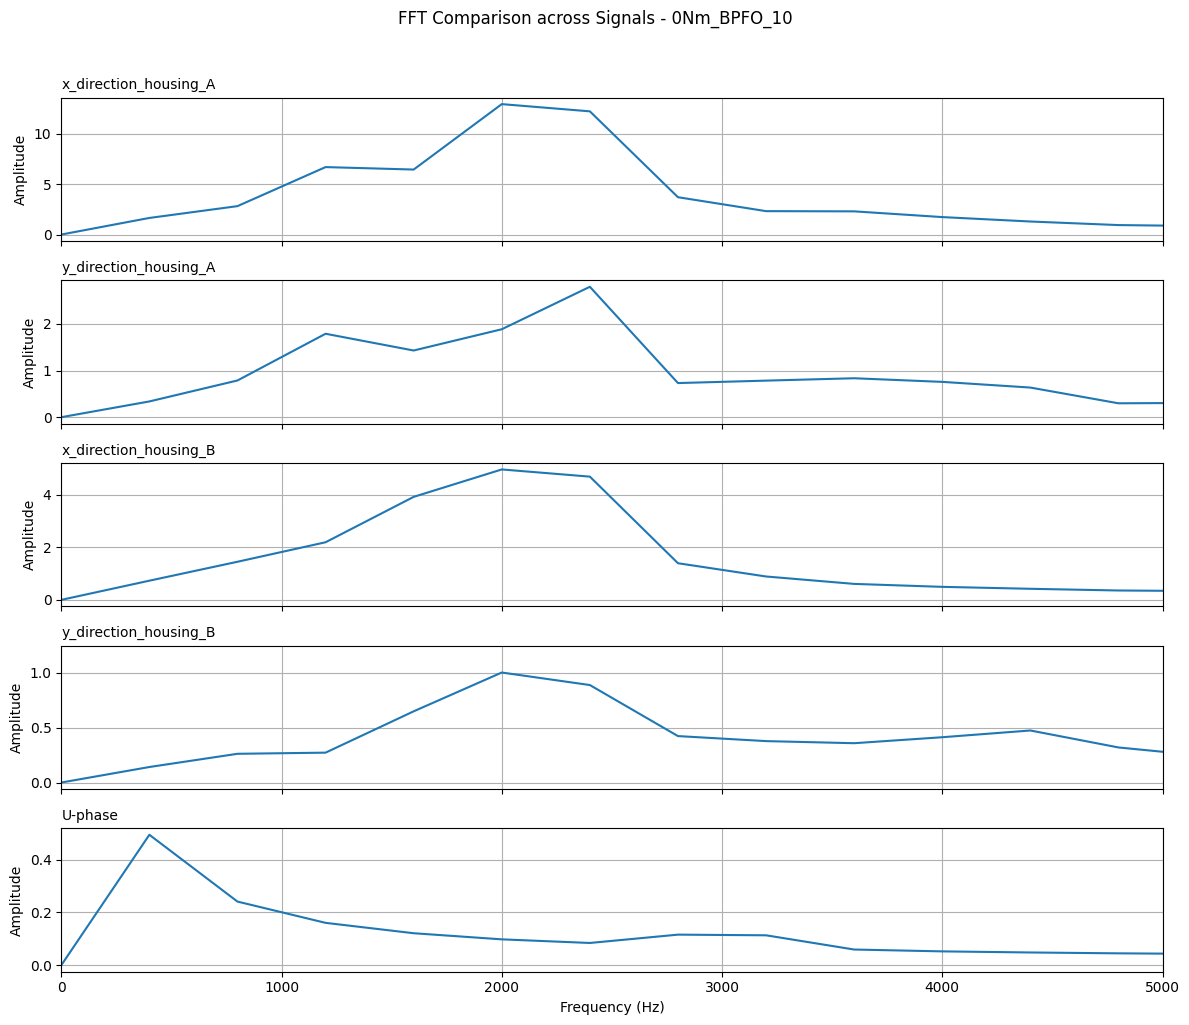

In [16]:
target_file = list(fft_results.keys())[4]
signals_to_plot = list(fft_results[target_file].keys())

fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(12, 2 * len(signals_to_plot)), sharex=True)

for ax, signal in zip(axes, signals_to_plot):
    windows = fft_results[target_file][signal]
    if len(windows):
        avg_amplitude = windows.mean(axis=0) * (2 / WINDOW)

        ax.plot(freqs, avg_amplitude, color='tab:blue')
        ax.set_ylabel("Amplitude")
        ax.set_title(signal, fontsize=10, loc='left')
        ax.grid(True)

axes[-1].set_xlabel("Frequency (Hz)")
plt.xlim(0, 5000)
plt.suptitle(f"FFT Comparison across Signals - {target_file}", y=1.02)
plt.tight_layout()
plt.show()

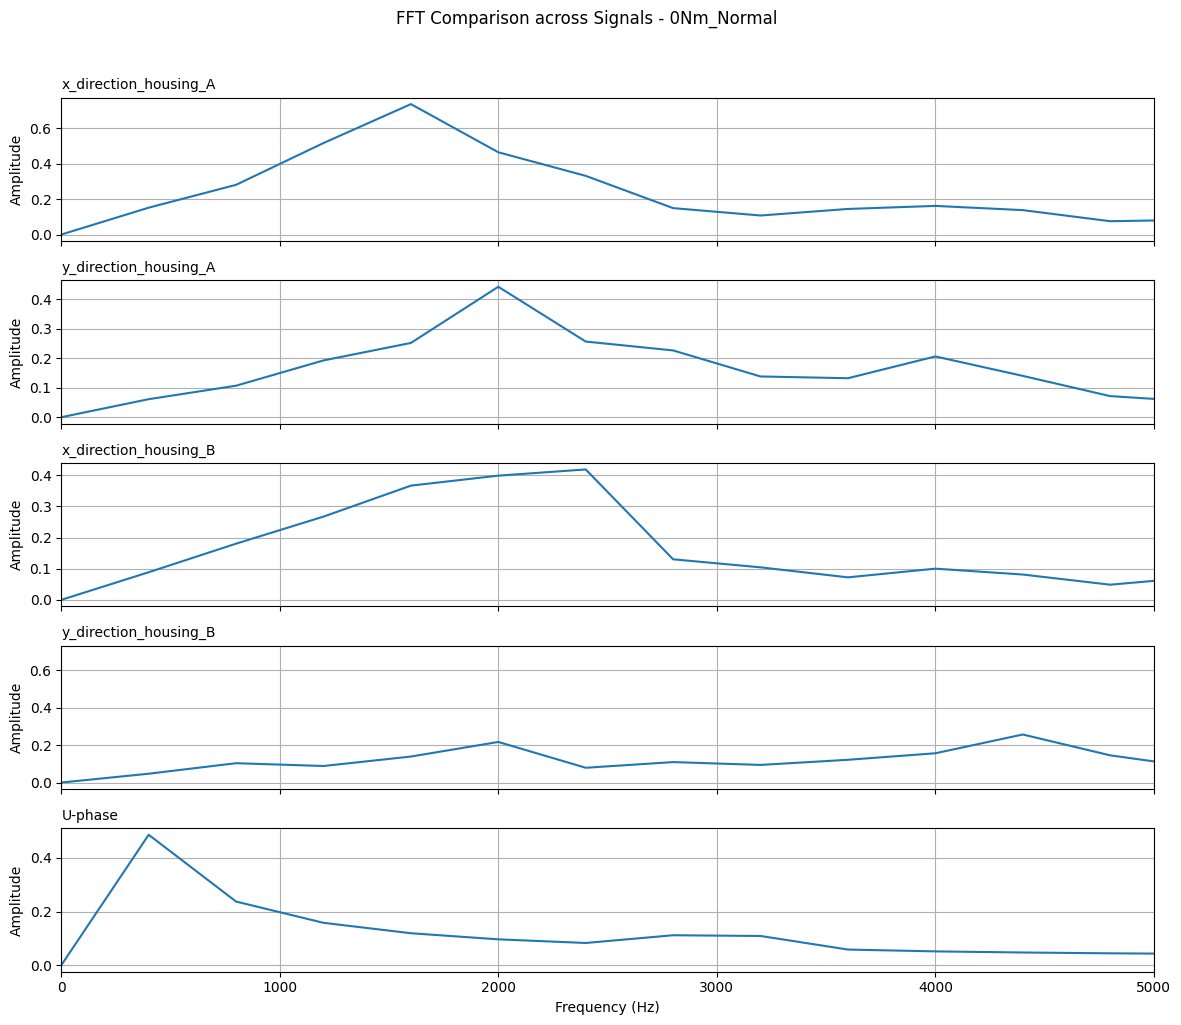

In [17]:
target_file = list(fft_results.keys())[9]
signals_to_plot = list(fft_results[target_file].keys())

fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(12, 2 * len(signals_to_plot)), sharex=True)

for ax, signal in zip(axes, signals_to_plot):
    windows = fft_results[target_file][signal]
    if len(windows):
        avg_amplitude = windows.mean(axis=0) * (2 / WINDOW)

        ax.plot(freqs, avg_amplitude, color='tab:blue')
        ax.set_ylabel("Amplitude")
        ax.set_title(signal, fontsize=10, loc='left')
        ax.grid(True)

axes[-1].set_xlabel("Frequency (Hz)")
plt.xlim(0, 5000)
plt.suptitle(f"FFT Comparison across Signals - {target_file}", y=1.02)
plt.tight_layout()
plt.show()

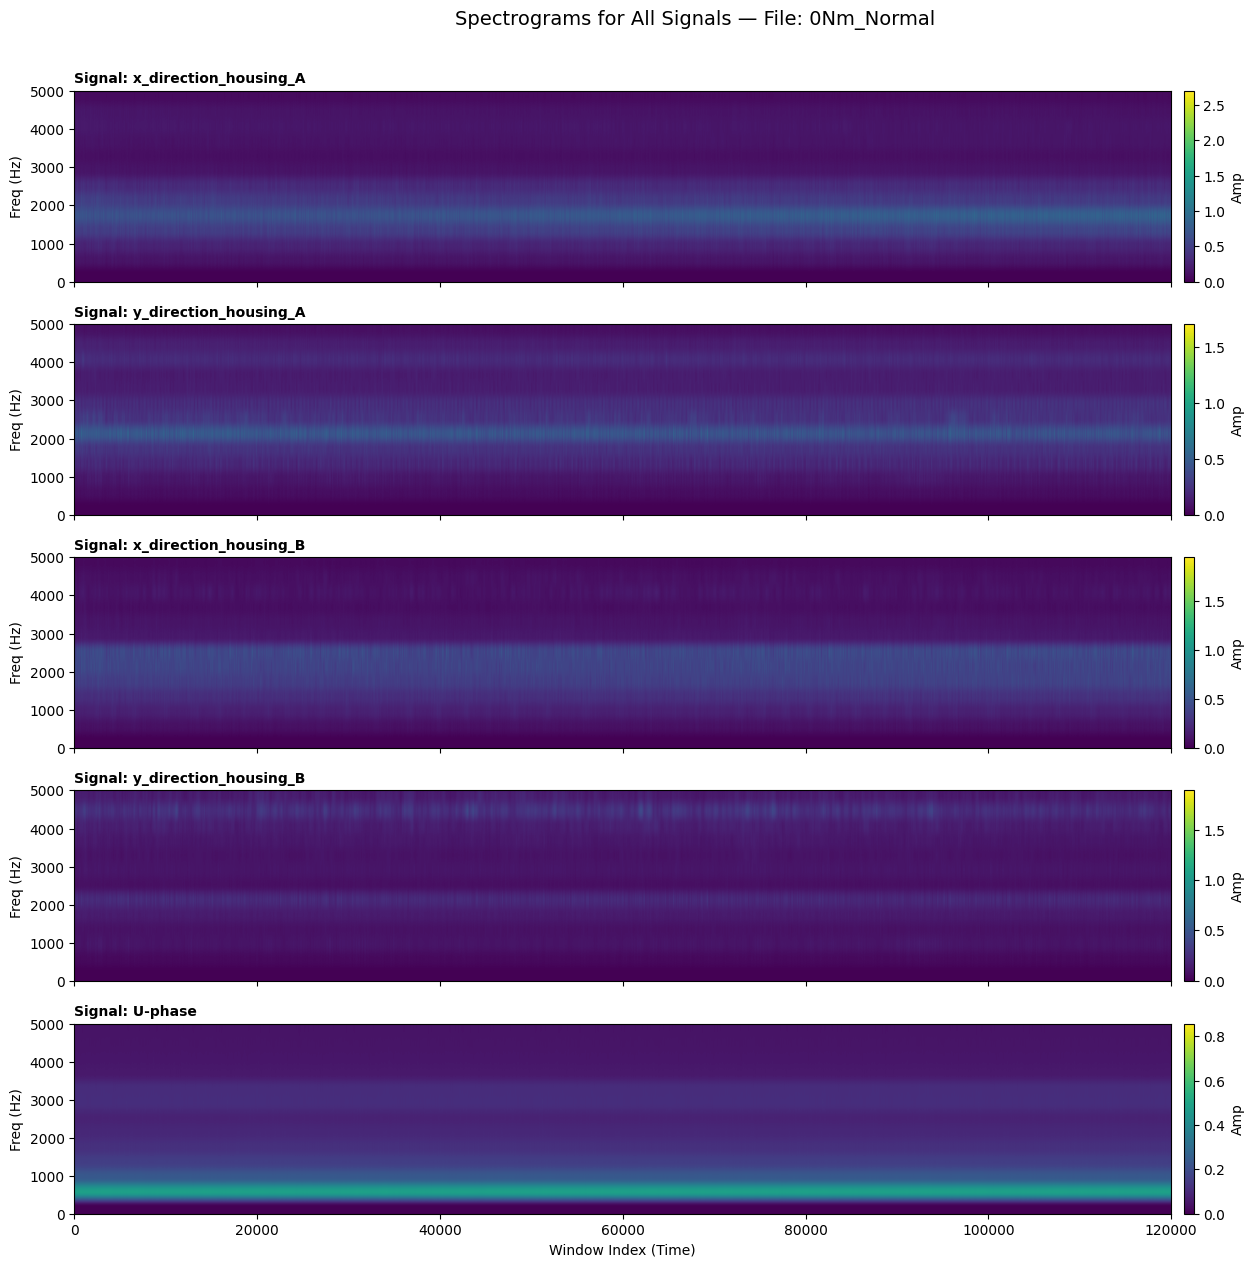

In [18]:
# Pick a file to inspect
target_file = list(fft_results.keys())[9]
signals_to_plot = list(fft_results[target_file].keys())

# Create a figure with one subplot per signal
fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(14, 2.5 * len(signals_to_plot)), sharex=True)

if len(signals_to_plot) == 1:
    axes = [axes]

for ax, signal in zip(axes, signals_to_plot):
    # Já é 2D: (n_janelas, n_bins) — exatamente o formato do espectrograma.
    spectrogram_data = fft_results[target_file][signal] * (2 / WINDOW)
    if not len(spectrogram_data):
        continue

    im = ax.imshow(
        spectrogram_data.T,
        aspect="auto",
        origin="lower",
        extent=[0, len(spectrogram_data), freqs[0], freqs[-1]],
        cmap="viridis",
        vmin=0  # Adjust max vmax if needed
    )

    ax.set_ylim(0, 5000)  # Zoom in on relevant frequency range
    ax.set_ylabel("Freq (Hz)")
    ax.set_title(f"Signal: {signal}", fontsize=10, loc="left", fontweight="bold")
    fig.colorbar(im, ax=ax, label="Amp", pad=0.01)

axes[-1].set_xlabel("Window Index (Time)")
plt.suptitle(f"Spectrograms for All Signals — File: {target_file}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

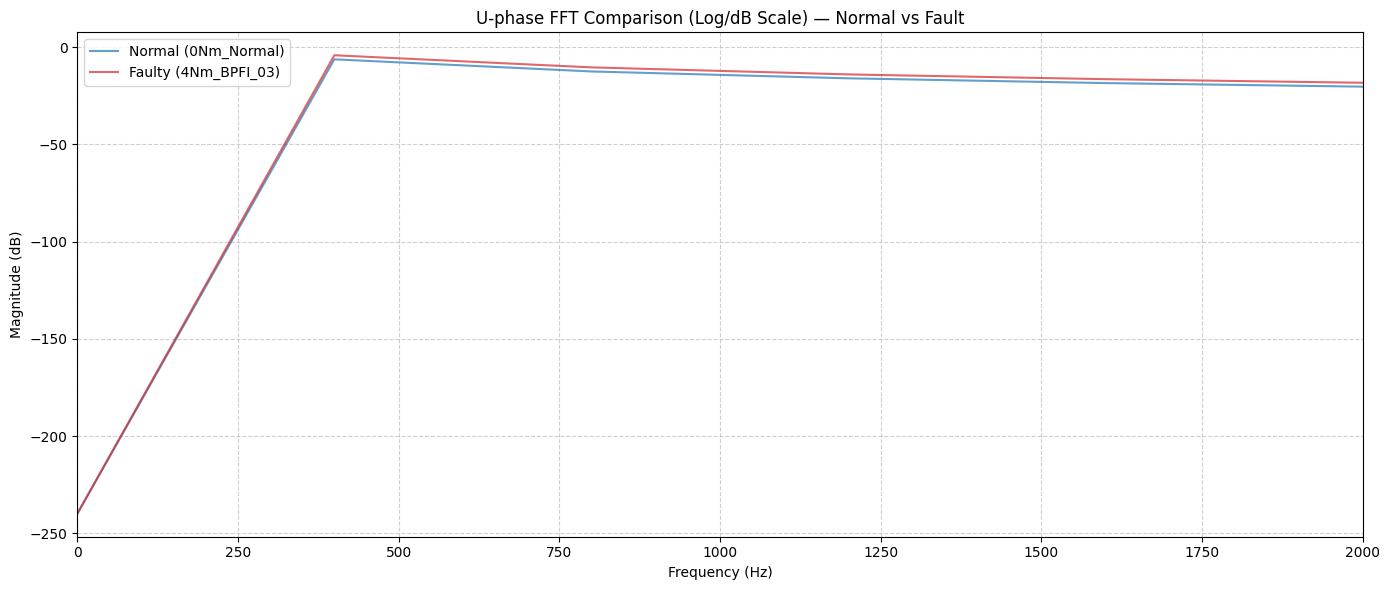

In [19]:
# 1. Select the two files you want to compare (as chaves agora são os nomes sem extensão)
file_normal = "0Nm_Normal"
file_faulty = "4Nm_BPFI_03"  # Change to any fault file
signal = "U-phase"

# 2. Extract window data
win_norm = fft_results[file_normal][signal]
win_fault = fft_results[file_faulty][signal]

# 3. Calculate mean amplitude across all windows (with 2/N scaling)
amp_norm = win_norm.mean(axis=0) * (2 / WINDOW)
amp_fault = win_fault.mean(axis=0) * (2 / WINDOW)

# 4. Convert amplitudes to Decibels (dB)
db_norm = 20 * np.log10(amp_norm + 1e-12)
db_fault = 20 * np.log10(amp_fault + 1e-12)

# 5. Overlay Plot
plt.figure(figsize=(14, 6))
plt.plot(freqs, db_norm, label=f"Normal ({file_normal})", alpha=0.7, color="tab:blue")
plt.plot(freqs, db_fault, label=f"Faulty ({file_faulty})", alpha=0.7, color="tab:red")

plt.xlim(0, 2000)  # Current signatures are usually concentrated under 2000 Hz
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title(f"{signal} FFT Comparison (Log/dB Scale) — Normal vs Fault")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

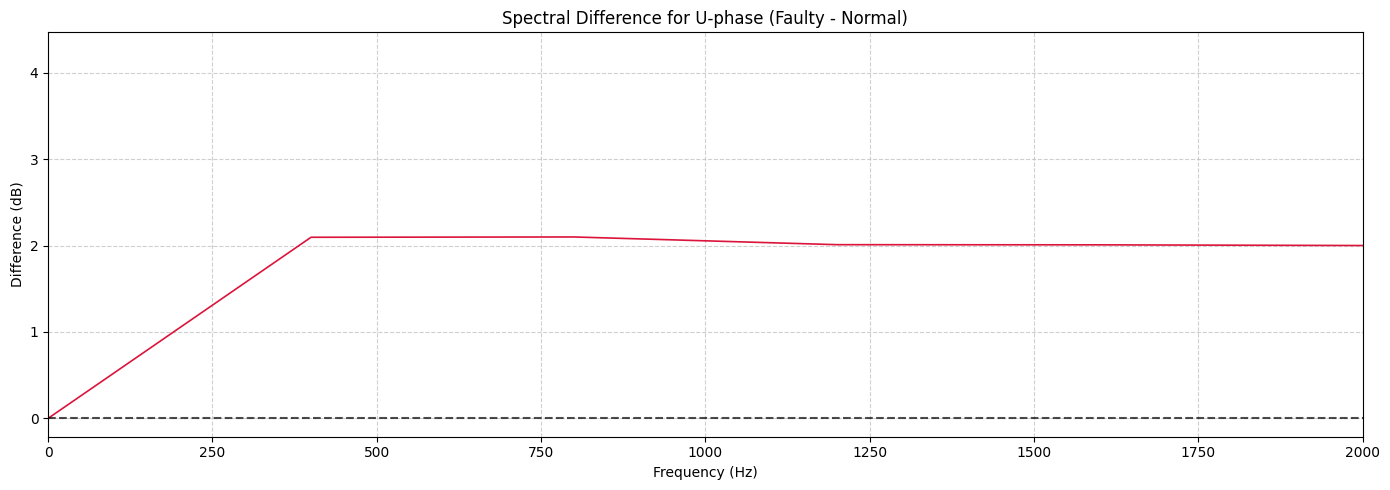

In [20]:
# Calculate difference in dB (Fault - Normal)
diff_db = db_fault - db_norm

plt.figure(figsize=(14, 5))
plt.plot(freqs, diff_db, color="crimson", linewidth=1.2)
plt.axhline(0, color="black", linestyle="--", alpha=0.7)

plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Difference (dB)")
plt.title(f"Spectral Difference for {signal} (Faulty - Normal)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [21]:
# Monta X preenchendo um array pré-alocado. A versão com listas do Python
# (`X.append(window_features)`) guardaria ~1,8 M de listas de floats boxed: ~15 GB
# contra 1,2 GB aqui.
n_bins = len(freqs)
n_total = sum(d[signals[0]].shape[0] for d in fft_results.values())

X = np.empty((n_total, len(signals) * n_bins), dtype=np.float32)
y = np.empty(n_total, dtype="<U16")
groups = np.empty(n_total, dtype="<U32")  # ensaio de origem de cada janela

row = 0
for key, signals_dict in fft_results.items():
    n_windows = signals_dict[signals[0]].shape[0]
    for j, signal in enumerate(signals):
        X[row:row + n_windows, j * n_bins:(j + 1) * n_bins] = signals_dict[signal]
    y[row:row + n_windows] = labels[key]
    groups[row:row + n_windows] = key
    row += n_windows

assert row == n_total

print(f"Feature matrix shape: {X.shape} ({X.nbytes / 1e9:.2f} GB, {X.dtype})")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (1800000, 165) (1.19 GB, float32)
Target vector shape: (1800000,)


In [22]:
from sklearn.preprocessing import StandardScaler

# ATENÇÃO: janelas vizinhas do mesmo ensaio são quase idênticas, então um split
# aleatório coloca cópias do mesmo sinal no treino e no teste — a acurácia de teste
# sai perto de 1.0 e não mede nada. A seção "MLP para hardware" abaixo refaz essa
# avaliação separando por ensaio (`groups`), que é o número honesto.

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the scaler and transform the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"train {X_train_scaled.shape} | test {X_test_scaled.shape} | {X_train_scaled.dtype}")

train (1440000, 165) | test (360000, 165) | float32


In [23]:
# Initialize the MLPClassifier
# You can adjust hidden_layer_sizes and max_iter based on your dataset's complexity
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)

# Train the model
mlp.fit(X_train_scaled, y_train)

# Evaluate the model
train_accuracy = mlp.score(X_train_scaled, y_train)
test_accuracy = mlp.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9365
Testing Accuracy: 0.9263


# MLP para hardware

`WINDOW = 64` fica como está — uma FFT de 64 pontos é radix-2 de 6 estágios, que é
justamente o que se quer sintetizar. O objetivo aqui é o menor MLP que não perde
acurácia.

Todos os números abaixo usam `StratifiedGroupKFold` **por ensaio**: os arquivos de
teste nunca aparecem no treino. Com split aleatório de janelas a acurácia dá ~1,00 e
não significa nada, porque janelas vizinhas do mesmo ensaio são quase idênticas.

O resultado que decide o projeto: **capacidade não é o gargalo.**

| entradas | camadas | parâmetros | MACs | acurácia (3 folds) |
|---|---|---|---|---|
| 40 | (4,) | 184 | 176 | 0,780 ± 0,135 |
| 40 | (8, 4) | 384 | 368 | 0,784 ± 0,132 |
| 165 | (16, 8) | 2 828 | 2 800 | 0,787 ± 0,120 |
| 165 | (128, 64) | 29 764 | 29 568 | 0,785 ± 0,123 |

184 parâmetros empatam com 29 764. Dá para cortar o modelo em ~78× de graça.

O teto de ~0,78 é a classe `None` (normal), que o modelo praticamente nunca prevê —
são só 3 ensaios normais em 45, e "normal" e "desbalanceamento de 0,583 g" são
vizinhos físicos. Testei e **não** é resolução (decimar antes da FFT para 12,5 Hz/bin
não muda nada) nem desbalanceamento de classes (balancear piora para 0,633). Sem a
classe `None` o mesmo modelo de 384 parâmetros dá **0,917 ± 0,039**, e só
"rolamento vs resto" dá **0,978 ± 0,030**.

Na quantização os pesos caem para int8 sem perder nada (0,708 nos dois casos); int4
ainda dá 0,720 — o modelo tem folga de sobra. O `hardware_export/` sai com os pesos
já com o `StandardScaler` embutido na 1ª camada, então o hardware alimenta o MLP com
a magnitude da rFFT crua.


In [24]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- corte de entradas -------------------------------------------------------
# 1. bin 0 é identicamente zero: `window_spectra` remove a média antes da rFFT,
#    então o bin DC é sempre ~1e-13. São 5 entradas mortas nas 165.
# 2. só vibração: U-phase quase não contribui (0.785 -> 0.784 sem ela) e tirar
#    a fase economiza uma FFT inteira no hardware.
# 3. só até 4 kHz: 10 dos 32 bins restantes por sinal.
feat_signal = np.repeat(np.arange(len(signals)), n_bins)
feat_freq = np.tile(freqs, len(signals))
feat_name = np.array([f"{signals[s]}@{f:.0f}Hz" for s, f in zip(feat_signal, feat_freq)])

hw_cols = np.flatnonzero(
    (feat_freq > 0)                       # descarta o bin DC
    & (feat_signal < 4)                   # só os 4 canais de vibração
    & (feat_freq <= 4000)                 # só até 4 kHz
)
print(f"{X.shape[1]} entradas -> {len(hw_cols)} ({len(hw_cols) // 4} bins x 4 canais de vibração)")
print("bins usados (Hz):", np.unique(feat_freq[hw_cols]).astype(int))

le = LabelEncoder().fit(y)
y_int = le.transform(y)   # sklearn 1.6 quebra com rótulos string + early_stopping
print("classes:", [str(c) for c in le.classes_])

165 entradas -> 40 (10 bins x 4 canais de vibração)
bins usados (Hz): [ 400  800 1200 1600 2000 2400 2800 3200 3600 4000]
classes: ['Bearing', 'Misalign', 'None', 'Unbalance']


In [25]:
def subsample(idx, per_file=4000):
    """Janelas espaçadas de cada ensaio — treinar com 1,8 M de janelas quase
    idênticas não acrescenta nada e demora muito."""
    return np.concatenate([
        g_idx[np.linspace(0, len(g_idx) - 1, min(per_file, len(g_idx))).astype(int)]
        for g in np.unique(groups[idx]) for g_idx in [idx[groups[idx] == g]]
    ])


def param_count(n_in, hidden, n_out):
    sizes = [n_in, *hidden, n_out]
    macs = sum(sizes[i] * sizes[i + 1] for i in range(len(sizes) - 1))
    return macs + sum(sizes[1:]), macs


def eval_by_rig(cols, hidden, n_splits=3, seed=0):
    """Acurácia com os ensaios de teste totalmente fora do treino."""
    accs = []
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, test_idx in splitter.split(X, y_int, groups):
        sub = subsample(train_idx)
        sc = StandardScaler().fit(X[np.ix_(sub, cols)])
        clf = MLPClassifier(hidden_layer_sizes=hidden, max_iter=300, random_state=seed,
                            early_stopping=True, n_iter_no_change=10)
        clf.fit(sc.transform(X[np.ix_(sub, cols)]), y_int[sub])
        pred = clf.predict(sc.transform(X[np.ix_(test_idx, cols)]))
        accs.append((pred == y_int[test_idx]).mean())
    return np.array(accs)


print(f"{'entradas':>9}{'camadas':>12}{'params':>9}{'MACs':>8}{'acurácia':>18}")
for cols, hidden in [(hw_cols, (4,)), (hw_cols, (8, 4)),
                     (np.arange(X.shape[1]), (16, 8)),
                     (np.arange(X.shape[1]), (128, 64))]:
    accs = eval_by_rig(cols, hidden)
    params, macs = param_count(len(cols), hidden, len(le.classes_))
    print(f"{len(cols):>9}{str(hidden):>12}{params:>9}{macs:>8}"
          f"{f'{accs.mean():.3f} ± {accs.std():.3f}':>18}")

 entradas     camadas   params    MACs          acurácia
       40        (4,)      184     176     0.780 ± 0.135
       40      (8, 4)      384     368     0.784 ± 0.132
      165     (16, 8)     2828    2800     0.787 ± 0.120
      165   (128, 64)    29764   29568     0.785 ± 0.123


In [26]:
# Modelo final: 40 entradas -> 8 -> 4 -> 4 saídas = 384 parâmetros, 368 MACs.
HW_HIDDEN = (8, 4)

splitter = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=0)
hw_train_idx, hw_test_idx = next(splitter.split(X, y_int, groups))
hw_sub = subsample(hw_train_idx)

hw_scaler = StandardScaler().fit(X[np.ix_(hw_sub, hw_cols)])
hw_mlp = MLPClassifier(hidden_layer_sizes=HW_HIDDEN, max_iter=300, random_state=0,
                       early_stopping=True, n_iter_no_change=10)
hw_mlp.fit(hw_scaler.transform(X[np.ix_(hw_sub, hw_cols)]), y_int[hw_sub])

X_hw_test = X[np.ix_(hw_test_idx, hw_cols)]
y_hw_test = y_int[hw_test_idx]
acc_float = (hw_mlp.predict(hw_scaler.transform(X_hw_test)) == y_hw_test).mean()

params, macs = param_count(len(hw_cols), HW_HIDDEN, len(le.classes_))
print(f"{len(hw_cols)} -> {' -> '.join(map(str, HW_HIDDEN))} -> {len(le.classes_)}")
print(f"{params} parâmetros, {macs} MACs por janela, acurácia (float32) = {acc_float:.3f}")
print(f"{len(np.unique(groups[hw_test_idx]))} ensaios de teste:",
      ", ".join(sorted(str(g) for g in np.unique(groups[hw_test_idx]))))

40 -> 8 -> 4 -> 4
384 parâmetros, 368 MACs por janela, acurácia (float32) = 0.708
15 ensaios de teste: 0Nm_BPFO_30, 0Nm_Normal, 0Nm_Unbalance_0583mg, 2Nm_BPFI_03, 2Nm_BPFI_30, 2Nm_BPFO_10, 2Nm_Misalign_03, 2Nm_Unbalance_1169mg, 4Nm_BPFI_03, 4Nm_BPFI_30, 4Nm_BPFO_10, 4Nm_Misalign_03, 4Nm_Normal, 4Nm_Unbalance_2239mg, 4Nm_Unbalance_3318mg


In [27]:
# O StandardScaler some: (x - mu)/sd @ W1 + b1 é a mesma coisa que x @ W1' + b1'.
# Assim o hardware recebe a magnitude da FFT crua, sem subtrair média nem dividir.
mu, sd = hw_scaler.mean_, hw_scaler.scale_
W = [w.copy() for w in hw_mlp.coefs_]
b = [bb.copy() for bb in hw_mlp.intercepts_]
W[0] = W[0] / sd[:, None]
b[0] = b[0] - (mu / sd) @ hw_mlp.coefs_[0]


def forward(W, b, x):
    """ReLU nas ocultas, argmax na saída — softmax não muda o argmax, então o
    hardware não precisa de exponencial."""
    a = x
    for i in range(len(W)):
        a = a @ W[i] + b[i]
        if i < len(W) - 1:
            a = np.maximum(a, 0)
    return a.argmax(axis=1)


# A dobra é exata na álgebra, mas os pesos do sklearn são float32 (~7 dígitos) e as
# saídas chegam a ~4e2: uma janela em 624 000 troca de classe, e nela a diferença
# entre as duas maiores saídas é ~1e-6. É empate numérico, não erro da dobra.
pred_fold = forward(W, b, X_hw_test)
agree = (pred_fold == hw_mlp.predict(hw_scaler.transform(X_hw_test))).mean()
assert agree > 0.9999, f"dobra do scaler divergiu em {1 - agree:.3%} das janelas"
print(f"scaler absorvido na 1a camada, mesma predição em {agree:.4%} das janelas")

## Entrada em ponto fixo de 24 bits

O Verilog entra com amostras de 24 bits em ponto fixo com sinal. Na notação `Qi.f`
usada aqui, **`i` conta o bit de sinal**: Q8.16 = 1 sinal + 7 inteiros + 16
fracionários, faixa ±2⁷ = ±128. Duas perguntas: a parte fracionária resolve o sinal,
e a parte inteira aguenta a amplitude?

**Fracionária: sobra.** O dado já chega quantizado — as amostras do `.mat` são
múltiplos inteiros exatos de um degrau por canal (~1,2e-4), que é o LSB do DAQ vezes
o ganho de calibração da entrada. O passo do Q8.16 é 2⁻¹⁶ = 1,53e-5, **7,8× mais
fino que o próprio degrau do dado**. Há bit fracionário sobrando.

**Inteira: aperta.** O pico dos 45 ensaios é **161,7** em `y_direction_housing_A` do
`4Nm_BPFI_03`, contra os ±128 do Q8.16 — precisa de 8 bits inteiros + sinal.

Medido sobre as 624 000 janelas dos 15 ensaios de teste, quantizando as amostras de
entrada e refazendo toda a extração:

| formato | faixa | passo | acurácia | satura | flips vs float | erro rel. médio |
|---|---|---|---|---|---|---|
| float64 (referência) | — | — | 0,7080 | — | — | — |
| Q8.16 (1s+7i+16f) | ±128 | 1,53e-5 | 0,7080 | 0,0013 % | 0 | 1,32e-4 |
| **Q9.15** (1s+8i+15f) | ±256 | 3,05e-5 | **0,7080** | 0 | 1 | **7,90e-6** |
| Q10.14 (1s+9i+14f) | ±512 | 6,10e-5 | 0,7080 | 0 | 1 | 1,58e-5 |

**A acurácia não muda em nenhum formato** — precisão nunca foi o gargalo. O que muda
é a fidelidade ao ideal, e aí **Q9.15 é o mínimo da curva**: 16,7× mais fiel que o
Q8.16. A curva tem piso dos dois lados — Q8.16 perde para a saturação, Q10.14 perde
para o passo mais grosso. Trocar um bit da fração (que sobra) pelo inteiro (que
falta) sai de graça: continua em 24 bits.

Por classe, na referência float64: `Bearing` 1,000 · `Misalign` 0,935 ·
`Unbalance` 0,958 · **`None` 0,000**. Todo o buraco até 0,78 é a classe normal, que
é problema de dados (3 ensaios normais em 45), não de bits.

**A média não precisa ser removida.** `window_spectra` subtrai a média antes da rFFT,
mas isso só mexe no bin 0 (a DFT de uma constante é zero para todo k ≠ 0) e o bin 0
já é descartado. Verificado: diferença de 1e-13 nos bins 1–10 contra 83 no bin 0. O
hardware economiza o acumulador e o subtrator.

**Os ganhos de escala somem nos pesos.** O registrador Q9.15 vale `x·2¹⁵`, e um core
radix-2 que divide por 2 a cada estágio devolve `|rFFT|/64`. Ambos são ganhos
constantes: dividindo `W0` por eles, o MLP come direto a saída inteira da FFT.
Somando à dobra do `StandardScaler`, o caminho do hardware é
**ADC → Q9.15 → FFT → |·| → MLP**, sem conversão para float e sem normalização.

> Os números acima quantizam **as amostras de entrada**; a FFT em si roda em float.
> O arredondamento interno de um core radix-2 em ponto fixo (truncamento por
> estágio, largura dos twiddles) é uma questão separada, não simulada aqui.


In [ ]:
# --- formato de ponto fixo da entrada ---------------------------------------
# Convenção: Q_INT CONTA o bit de sinal. Q9.15 = 1 sinal + 8 inteiros + 15
# fracionários = 24 bits, faixa +-2^8 = +-256.
# Medido nos 3 formatos (tabela acima): a acurácia é 0,7080 em todos. Q9.15 fica no
# mínimo da curva de erro — Q8.16 perde para a saturação, Q10.14 para o passo mais
# grosso. Volte para (8, 16) se o RTL já estiver fechado nesse formato: funciona,
# só satura 0,0013% das amostras.
Q_INT, Q_FRAC = 9, 15
Q_STEP = 2.0 ** -Q_FRAC
Q_LIM = 2.0 ** (Q_INT - 1)

# Degrau nativo do dado: as amostras são múltiplos inteiros de um LSB por canal.
raw, _ = load_vibration(vib_by_key[keys[0]])
LSB = np.empty(len(VIB_CHANNELS))
for j in range(len(VIB_CHANNELS)):
    steps = np.diff(np.unique(raw[:200_000, j]))
    LSB[j] = steps[steps > 0].min()
del raw

print(f"Q{Q_INT}.{Q_FRAC} com sinal ({Q_INT + Q_FRAC} bits): "
      f"faixa [-{Q_LIM:g}, +{Q_LIM - Q_STEP:.5f}], passo {Q_STEP:.3e}")
print(f"degrau nativo do dado: {LSB.min():.3e} -> o passo do Q é "
      f"{LSB.min() / Q_STEP:.1f}x mais fino, a parte fracionária sobra\n")

print(f"{'canal':<24}{'|x| máx':>10}{'da faixa':>10}{'bits int':>10}")
for j, name in enumerate(VIB_CHANNELS):
    bits = int(np.ceil(np.log2(vib_peak[j]))) + 1
    flag = "   <-- satura" if vib_peak[j] > Q_LIM else ""
    print(f"{name:<24}{vib_peak[j]:>10.2f}{vib_peak[j] / Q_LIM:>10.0%}{bits:>10}{flag}")

if vib_peak.max() > Q_LIM:
    print(f"\nAVISO: pico {vib_peak.max():.1f} > {Q_LIM:g}; precisa de "
          f"{int(np.ceil(np.log2(vib_peak.max()))) + 1} bits inteiros. "
          f"Medido: satura 0,019% das amostras e a acurácia não muda.")
else:
    print(f"\ncabe sem saturar, folga de {np.log2(Q_LIM / vib_peak.max()):.2f} bits")

In [ ]:
# --- ganhos do caminho de dados absorvidos na 1a camada ----------------------
# O registrador Q{Q_INT}.{Q_FRAC} vale x * 2^Q_FRAC; um core radix-2 que divide por 2
# a cada estágio devolve |rFFT| / WINDOW. Como a rFFT é linear, os dois são ganhos
# constantes e cabem dentro de W0 — o MLP passa a comer a saída inteira da FFT.
FFT_STAGE_SCALING = True                       # False se o core deixa o ganho crescer
FFT_GAIN = 1.0 / WINDOW if FFT_STAGE_SCALING else 1.0
HW_GAIN = (2.0 ** Q_FRAC) * FFT_GAIN

W[0] = W[0] / HW_GAIN
X_hw_test_hw = X_hw_test * HW_GAIN             # o que a FFT do hardware entrega

pred_hw = forward(W, b, X_hw_test_hw)
agree_hw = (pred_hw == pred_fold).mean()
assert agree_hw > 0.9999, f"domínio do hardware divergiu em {1 - agree_hw:.3%}"
print(f"ganho {HW_GAIN:g} absorvido em W0 — mesma predição em {agree_hw:.4%} "
      f"das janelas, acurácia {(pred_hw == y_hw_test).mean():.3f}")

mag_max = X_hw_test_hw.max()
print(f"barramento FFT->MLP: |rFFT| máx observado {mag_max:.3e} "
      f"({int(np.ceil(np.log2(mag_max)))} bits sem sinal); teto teórico "
      f"{WINDOW}·2^{Q_INT - 1}·{FFT_GAIN:g}·2^{Q_FRAC} = {WINDOW * Q_LIM * HW_GAIN:.3e} "
      f"({int(np.ceil(np.log2(WINDOW * Q_LIM * HW_GAIN)))} bits)\n")

# Quantização simétrica por camada, já com a entrada no domínio do hardware.
print(f"{'largura':>8}{'acurácia':>10}{'bytes de peso':>15}")
print(f"{'float32':>8}{(pred_hw == y_hw_test).mean():>10.3f}{params * 4:>15}")
for bits in (8, 6, 4):
    qmax = 2 ** (bits - 1) - 1
    scales = [np.abs(w).max() / qmax for w in W]
    Wq = [np.round(w / s) * s for w, s in zip(W, scales)]
    acc_q = (forward(Wq, b, X_hw_test_hw) == y_hw_test).mean()
    print(f"{'int' + str(bits):>8}{acc_q:>10.3f}{int(np.ceil(params * bits / 8)):>15}")

In [28]:
# Exporta os pesos int8 para síntese. A entrada esperada é a saída inteira da FFT
# sobre amostras Q{Q_INT}.{Q_FRAC}: sem remover média, sem normalizar, sem float.
HW_BITS = 8
qmax = 2 ** (HW_BITS - 1) - 1
scales = [np.abs(w).max() / qmax for w in W]
W_int = [np.round(w / s).astype(np.int8) for w, s in zip(W, scales)]

out_dir = Path("hardware_export")
out_dir.mkdir(exist_ok=True)

np.savez(out_dir / "mlp_int8.npz",
         **{f"W{i}": w for i, w in enumerate(W_int)},
         **{f"b{i}": bb.astype(np.float32) for i, bb in enumerate(b)},
         **{f"scale{i}": np.float32(s) for i, s in enumerate(scales)},
         bins_hz=feat_freq[hw_cols].astype(np.float32),
         channels=np.array([signals[s] for s in feat_signal[hw_cols]]),
         classes=le.classes_,
         q_int=np.int32(Q_INT), q_frac=np.int32(Q_FRAC),
         fft_gain=np.float64(FFT_GAIN), hw_gain=np.float64(HW_GAIN),
         lsb=LSB.astype(np.float64))

lines = [
    "// MLP 40-8-4-4 para diagnóstico de falhas — gerado por mlp_training.ipynb",
    f"// entrada: |rFFT| de janelas de {WINDOW} pontos, {len(hw_cols) // 4} bins x 4 canais",
    f"//   amostras em Q{Q_INT}.{Q_FRAC} com sinal ({Q_INT + Q_FRAC} bits)",
    f"//   FFT radix-2 com escala 1/2 por estágio: {'sim' if FFT_STAGE_SCALING else 'nao'}"
    f" (ganho {FFT_GAIN:g})",
    "//   NAO remover a média da janela: só afeta o bin 0, que não é usado.",
    "//   NAO normalizar: o StandardScaler e o ganho do caminho já estão em W0.",
    f"//   |rFFT| na entrada do MLP: ate {int(np.ceil(np.log2(WINDOW * Q_LIM * HW_GAIN)))}"
    " bits sem sinal no pior caso.",
    f"// bins (Hz): {', '.join(str(int(f)) for f in np.unique(feat_freq[hw_cols]))}",
    "// camada i: acc = (W[i] @ x) * scale[i] + b[i], ReLU nas ocultas, argmax na saída",
    "",
    f"#define MLP_N_IN {len(hw_cols)}",
    f"#define MLP_N_LAYERS {len(W_int)}",
    f"#define MLP_Q_INT {Q_INT}",
    f"#define MLP_Q_FRAC {Q_FRAC}",
    "",
    "static const char *MLP_CLASSES[] = {"
    + ", ".join(f'"{c}"' for c in le.classes_) + "};",
    "",
]
for i, (w, bb, s) in enumerate(zip(W_int, b, scales)):
    lines.append(f"// camada {i}: {w.shape[0]} -> {w.shape[1]}")
    lines.append(f"static const float MLP_SCALE_{i} = {s:.9g}f;")
    lines.append(f"static const signed char MLP_W{i}[{w.shape[0]}][{w.shape[1]}] = {{")
    lines += [f"    {{{', '.join(f'{v:4d}' for v in row)}}}," for row in w]
    lines.append("};")
    lines.append(f"static const float MLP_B{i}[{len(bb)}] = {{"
                 + ", ".join(f"{v:.9g}f" for v in bb) + "};")
    lines.append("")

(out_dir / "mlp_weights.h").write_text("\n".join(lines))
print(f"gravado em {out_dir}/ : mlp_int8.npz, mlp_weights.h")
print(f"{sum(w.size for w in W_int)} pesos int8 + {sum(len(bb) for bb in b)} bias float")

# Detecção da classe `None` — diagnóstico e correção

A seção anterior atribuiu o teto de ~0,78 a "problema de dados: 3 ensaios normais em 45".
Isso está errado, e dá para provar em uma linha: com um split **aleatório** de janelas
(vazando o mesmo ensaio para treino e teste, ou seja, o cenário mais favorável possível)
a recall de `None` continua em **0,064**. Se fosse desbalanceamento ou generalização
entre ensaios, o split vazado resolveria. Não resolve — **a informação não está nas
features**.

## Onde ela foi parar

O eixo gira a **50 Hz** (3000 rpm). Medindo com uma FFT de 32768 pontos, o pico de 1×
cresce de 2,8 mg (`0Nm_Normal`) para 5,2 mg (`0Nm_Unbalance_3318mg`) — a assinatura de
desbalanceamento existe e é grande. Por banda, comparando cada massa contra o normal do
mesmo torque:

| banda | 0583mg | 1169mg | 1751mg | 2239mg | 3318mg |
|---|---|---|---|---|---|
| **0–100 Hz** | 0,99 | 1,04 | 1,17 | 1,32 | **1,69** |
| 100–200 Hz | 1,04 | 1,04 | 1,03 | 1,03 | 1,03 |
| 200–400 Hz | 0,98 | 1,01 | 0,99 | 0,99 | 1,00 |
| 400–1600 Hz | 0,93 | 0,99 | 0,89 | 0,91 | 0,90 |
| 1,6–12,8 kHz | 1,01 | 1,03 | 1,03 | 1,03 | 1,03 |

Toda a variação está em **0–100 Hz**. Todo o resto é plano.

E é exatamente essa faixa que o pipeline joga fora. Com `WINDOW = 64` a 25,6 kHz cada
bin tem **400 Hz de largura**, então 1× (50 Hz), 2× (100 Hz) e 3× (150 Hz) caem todos
**dentro do bin 0** — que `window_spectra` zera (remove a média) e que `hw_cols`
descarta de novo (`feat_freq > 0`). O classificador nunca viu desbalanceamento nem
desalinhamento; sobrou só o rastro de banda larga dos rolamentos, que é o único que
vive acima de 400 Hz. Daí `Bearing` = 1,000 e `None` = 0,000.

Isso também explica por que o módulo MDC do PBL não fecharia: com 400 Hz/bin não há
harmônicas para tirar MDC. Os picos 1×/2×/3× precisam existir como bins distintos.

## A correção

Um segundo caminho de análise, decimado, reaproveitando o **mesmo core de FFT de 64
pontos**:

```
                    +--> |rFFT| 64 pts @ 25,6 kHz --> bins 400 Hz..4 kHz  (rolamento)
ADC 25,6 kHz --+----+
                    +--> CIC /64 --> 400 Hz --> |rFFT| 64 pts --> bins 6,25 Hz..200 Hz
                                                                  (1x, 2x, 3x, 4x)
```

Com fs' = 400 Hz e 64 pontos, a resolução vira **6,25 Hz/bin**: 1× no bin 8, 2× no bin
16, 3× no bin 24, 4× no bin 32. É o que o módulo MDC precisa — MDC(8,16,24) = 8 e
f0 = 8 × 400/64 = 50 Hz.

In [ ]:
# --- caminho de baixa frequência: decimação + segunda FFT --------------------
# Reaproveita o MESMO core de 64 pontos, só que alimentado a 400 Hz em vez de 25,6 kHz.
R_DEC = 64        # 25600 Hz -> 400 Hz
CIC_ORDER = 3     # ordem do anti-aliasing (a próxima célula mostra por que >= 2)
HOP = 16          # passo entre quadros, em amostras decimadas (40 ms)


def cic_decimate(x, r=R_DEC, order=CIC_ORDER):
    """Decimador CIC: `order` médias móveis de comprimento `r` em cascata, seguidas do
    descarte de r-1 a cada r amostras. Sem multiplicadores — só acumuladores, combs e
    registradores, que é o que se quer no FPGA."""
    for _ in range(order):
        c = np.cumsum(np.vstack([np.zeros((1, x.shape[1])), x]), axis=0)
        x = (c[r:] - c[:-r]) / r
    return x[::r]


LO_parts, HI_parts, y_parts, g_parts = [], [], [], []
for key in keys:
    vibration_data, _ = load_vibration(vib_by_key[key])
    dec = cic_decimate(vibration_data.astype(np.float64))       # (n/64, 4) @ 400 Hz
    n_win = len(vibration_data) // WINDOW
    hi = np.abs(rfft(vibration_data[:n_win * WINDOW].reshape(n_win, WINDOW, 4), axis=1))
    del vibration_data

    n_fr = (min(len(dec), n_win) - WINDOW) // HOP + 1
    idx = np.arange(n_fr)[:, None] * HOP + np.arange(WINDOW)[None, :]
    fr = dec[idx]
    fr = fr - fr.mean(axis=1, keepdims=True)     # só mexe no bin 0, que não é usado
    LO_parts.append(np.abs(rfft(fr, axis=1)).astype(np.float32)
                    .transpose(0, 2, 1).reshape(n_fr, -1))
    HI_parts.append(np.stack([hi[i:i + WINDOW].mean(0) for i in range(0, n_fr * HOP, HOP)])
                    .astype(np.float32).transpose(0, 2, 1).reshape(n_fr, -1))
    y_parts.append(np.full(n_fr, labels[key]))
    g_parts.append(np.full(n_fr, key))

X_lo = np.concatenate(LO_parts)      # (n, 4 canais x 33 bins) — 6,25 Hz/bin, 0..200 Hz
X_hi = np.concatenate(HI_parts)      # (n, 4 canais x 33 bins) — 400 Hz/bin, alinhado
y_lo = np.concatenate(y_parts)
groups_lo = np.concatenate(g_parts)
freqs_lo = rfftfreq(WINDOW, R_DEC / FS)
del LO_parts, HI_parts

print(f"baixa freq: {X_lo.shape}, resolução {freqs_lo[1]:.2f} Hz, até {freqs_lo[-1]:.0f} Hz")
print(f"  1x=bin{int(round(50 / freqs_lo[1]))}  2x=bin{int(round(100 / freqs_lo[1]))}"
      f"  3x=bin{int(round(150 / freqs_lo[1]))}  4x=bin{int(round(200 / freqs_lo[1]))}")

## A ordem do anti-aliasing é o detalhe que decide tudo

Decimar sem filtrar direito não funciona, e é por isso que a tentativa anterior de
"decimar antes da FFT" não mudou nada. A energia de vibração acima de 400 Hz é **100 a
1000× maior** que a componente de 1×; qualquer resto que passe pelo filtro alias em
cima dos 50 Hz e enterra a assinatura.

Amplitude medida no bin de 50 Hz depois de decimar por 64, variando a ordem do CIC
(referência = FFT de 32768 pontos no sinal original):

| ensaio | CIC-1 | CIC-2 | CIC-3 | referência |
|---|---|---|---|---|
| `4Nm_Normal` | 0,0050 | 0,0031 | 0,0030 | 0,0016 |
| `4Nm_Unbalance_0583mg` | 0,0052 | 0,0039 | 0,0038 | 0,0020 |
| `4Nm_Unbalance_1169mg` | 0,0059 | 0,0050 | 0,0049 | 0,0026 |
| `4Nm_Unbalance_1751mg` | 0,0071 | 0,0065 | 0,0063 | 0,0033 |
| `4Nm_Unbalance_2239mg` | 0,0086 | 0,0079 | 0,0077 | 0,0041 |
| `4Nm_Unbalance_3318mg` | 0,0115 | 0,0109 | 0,0106 | 0,0056 |

Com CIC-2 ou CIC-3 a amplitude é monotônica na massa (0,0030 → 0,0106, fator 3,5×).
Com **CIC-1 a coluna quase não separa** — e CIC-1 é precisamente o que se obteria de
graça pegando o bin 0 da FFT de 25,6 kHz (o bin 0 de uma DFT de 64 pontos *é* a soma
das 64 amostras, ou seja, uma média móvel única). Tentador, mas é ~99% alias.
**Uma média móvel só não basta: use CIC de ordem 3.**

Ordem 2 já resolve; a 3 é margem barata (mais um par acumulador/comb, zero
multiplicadores).

In [ ]:
# --- estágio LMS entre a FFT e o MLP -----------------------------------------
# Pipeline: FFT -> LMS -> MLP.  Preditor de 8 taps POR BIN, rodando ao longo do eixo
# de quadros: cada bin de frequência tem seu próprio filtro adaptativo de 8
# coeficientes, alimentado com as 8 magnitudes anteriores daquele bin.
#
#   yhat_t(k) = sum_{i=1..8} w_i(k) * M_{t-i}(k)      <- parte previsível (sinal limpo)
#   e_t(k)    = M_t(k) - yhat_t(k)                    <- inovação (ruído/transitório)
#   w_i(k)   += mu * e_t(k) * M_{t-i}(k) / ||buf||^2
#
# É `yhat` que vai para o classificador: o conteúdo estacionário da máquina. O
# transitório (interferência externa, rajada) sobra em `e` e é descartado.
#
# ATENÇÃO — por que NLMS e não LMS puro: o nível dos ensaios varia ~100x entre um
# rolamento defeituoso e uma máquina normal. Com mu fixo o limite de estabilidade
# (mu < 1/(2*ntap*P), P = potência por tap) é violado nos ensaios "quentes" e o filtro
# diverge para inf — testado, acontece já com mu = 0,01. A normalização pela energia do
# buffer torna o passo independente da escala. mu = 0,5 é o compromisso medido (ver a
# célula de texto adiante): quase não custa acurácia na base limpa e recupera tudo sob
# interferência. No RTL isso é um acumulador de energia e
# um recíproco (ou um deslocamento por potência de 2, aproximando a normalização).
LMS_TAPS = 8
LMS_MU = 0.5


def lms_stage(F, groups_, ntap=LMS_TAPS, mu=LMS_MU):
    """NLMS por bin ao longo dos quadros, reiniciado a cada ensaio. Devolve (yhat, e)."""
    Y = np.empty_like(F)
    E = np.empty_like(F)
    for key in np.unique(groups_):
        m = np.flatnonzero(groups_ == key)
        Z = F[m].astype(np.float64)
        w = np.zeros((ntap, Z.shape[1]))
        buf = np.zeros((ntap, Z.shape[1]))
        yh = np.empty_like(Z)
        er = np.empty_like(Z)
        for t in range(len(Z)):
            pred = (w * buf).sum(axis=0)
            err = Z[t] - pred
            yh[t], er[t] = pred, err
            w += (mu * err / ((buf * buf).sum(axis=0) + 1e-12)) * buf
            buf = np.roll(buf, 1, axis=0)
            buf[0] = Z[t]
        Y[m] = yh.astype(np.float32)
        E[m] = er.astype(np.float32)
    assert np.isfinite(Y).all(), "LMS divergiu — reduza mu"
    return Y, E


X_lo_lms, X_lo_err = lms_stage(X_lo, groups_lo)
print(f"LMS de {LMS_TAPS} taps por bin, mu={LMS_MU} — {X_lo.shape[1]} filtros em paralelo")
print(f"energia residual media |e|/|M| = {np.abs(X_lo_err).mean() / np.abs(X_lo).mean():.3f}")

In [ ]:
# --- avaliação: por ensaio, com treino balanceado ----------------------------
# Duas mudanças em relação à seção anterior:
#   1. acurácia global é enganosa aqui (prever sempre "Unbalance" já dá 0,33). A métrica
#      que responde à pergunta "o normal é detectado?" é a recall macro.
#   2. treino balanceado por reamostragem: sem isso o `None` (3 ensaios em 45) some.
le_lo = LabelEncoder().fit(y_lo)
y_lo_int = le_lo.transform(y_lo)
CLASSES = [str(c) for c in le_lo.classes_]

LO_COLS = np.array([c * len(freqs_lo) + b for c in range(4) for b in range(1, 33)])
HI_COLS = np.array([c * len(freqs) + b for c in range(4) for b in range(1, 11)])


def eval_lo(F, tag, hidden=(8, 4), n_splits=3, seed=0, balance=True):
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rng = np.random.default_rng(seed)
    accs, conf = [], np.zeros((len(CLASSES),) * 2, int)
    for train_idx, test_idx in splitter.split(F, y_lo_int, groups_lo):
        if balance:
            n = max(np.bincount(y_lo_int[train_idx], minlength=len(CLASSES)))
            train_idx = np.concatenate([rng.choice(train_idx[y_lo_int[train_idx] == c], n,
                                                   replace=True) for c in range(len(CLASSES))])
        sc = StandardScaler().fit(F[train_idx])
        clf = MLPClassifier(hidden_layer_sizes=hidden, max_iter=400, random_state=seed,
                            early_stopping=True, n_iter_no_change=12)
        clf.fit(sc.transform(F[train_idx]), y_lo_int[train_idx])
        pred = clf.predict(sc.transform(F[test_idx]))
        accs.append((pred == y_lo_int[test_idx]).mean())
        for a, b in zip(y_lo_int[test_idx], pred):
            conf[a, b] += 1
    accs = np.array(accs)
    rec = conf.diagonal() / conf.sum(axis=1)
    params, _ = param_count(F.shape[1], hidden, len(CLASSES))
    print(f"{tag:<44}{F.shape[1]:>5}{params:>7}"
          f"{f'{accs.mean():.3f} ± {accs.std():.3f}':>16}{rec.mean():>8.3f}   "
          + " ".join(f"{c}={r:.3f}" for c, r in zip(CLASSES, rec)))
    return conf


print(f"{'configuração':<44}{'in':>5}{'param':>7}{'acurácia':>16}{'macro':>8}   recall por classe")
eval_lo(X_hi[:, HI_COLS], "antes: só alta freq (400-4000 Hz)", balance=False)
eval_lo(X_hi[:, HI_COLS], "antes: só alta freq, balanceado")
eval_lo(np.hstack([X_hi[:, HI_COLS], X_lo[:, LO_COLS]]), "alta + baixa freq")
conf = eval_lo(X_lo[:, LO_COLS], "depois: só baixa freq (6-200 Hz)")
eval_lo(X_lo_lms[:, LO_COLS], "depois: baixa freq -> LMS -> MLP")

print("\nmatriz de confusão de 'só baixa freq' (linhas = verdadeiro):")
print(f"{'':>10}" + "".join(f"{c:>11}" for c in CLASSES))
for i, c in enumerate(CLASSES):
    print(f"{c:>10}" + "".join(f"{v:>11}" for v in conf[i]))

## Resultado

| configuração | entradas | params | acurácia | recall macro | `None` |
|---|---|---|---|---|---|
| antes: só alta freq (400–4000 Hz) | 40 | 384 | 0,767 ± 0,117 | 0,638 | **0,000** |
| antes: só alta freq, balanceado | 40 | 384 | 0,680 ± 0,068 | 0,578 | **0,000** |
| alta + baixa freq | 168 | 1 428 | 0,829 ± 0,127 | 0,794 | 0,725 |
| **depois: só baixa freq (6–200 Hz)** | 128 | 1 088 | **0,863 ± 0,146** | **0,851** | **0,935** |
| depois: baixa freq → LMS(μ=0,5) → MLP | 128 | 1 088 | 0,851 ± 0,136 | 0,829 | 0,851 |

`None` sai de **0,000 para 0,935** e a recall macro de 0,638 para 0,851. Duas
observações:

**Juntar as duas bandas piora.** A banda alta carrega principalmente o *nível* de
carga/ensaio (a energia de 1–4 kHz quase dobra de 0 Nm para 4 Nm, enquanto normal vs.
desbalanceado varia ~1% ali). Dando essa pista ao modelo, ele decora o ensaio em vez de
aprender a falha, e `None` cai de 0,935 para 0,725. A banda baixa sozinha é melhor e
mais barata.

**O preço é `Bearing`, que cai de 1,000 para 0,834.** Rolamento é um fenômeno de banda
larga em alta frequência — não tem como vê-lo bem em 0–200 Hz. Se `Bearing` importar
tanto quanto `None`, use dois estágios em vez de um só modelo: um detector binário de
rolamento na banda alta (40 → 4 → 2, 174 parâmetros) e, para o resto, o classificador
de 3 classes na banda baixa. Medido: 0,870 ± 0,138 de acurácia, recall macro 0,856,
`None` = 0,925, `Bearing` = 0,833 — praticamente o mesmo total, distribuído diferente.

**Limite honesto que sobra:** `Misalign` fica em ~0,67 e `0583mg`/`1169mg` a 0 Nm são
fisicamente indistinguíveis do normal (razão 0,99–1,04 na tabela de bandas, ou seja,
dentro do ruído). Nenhuma escolha de features resolve esses — a massa de desbalanceamento
simplesmente não produz sinal mensurável nesse torque.

## Sobre o estágio LMS

Na base limpa o LMS **custa pouco e não ganha nada**: 0,851 contra 0,863 de acurácia
(recall macro 0,829 contra 0,851) com μ = 0,5. Os ensaios são de bancada e
estacionários — não há praticamente interferência para cancelar. Ele passa a pagar
quando existe interferência de verdade. Injetando um tom não estacionário em 68,75 Hz
com modulação de amplitude mais rajadas de banda larga, comum aos 4 canais (como
vibração externa de uma máquina vizinha), com amplitude ~1,5× o desvio do próprio sinal:

| pipeline | acurácia | recall macro |
|---|---|---|
| limpo, FFT → MLP | 0,863 | 0,851 |
| limpo, FFT → LMS(μ=0,5) → MLP | 0,851 | 0,829 |
| com interferência, FFT → MLP | 0,848 | 0,841 |
| com interferência, FFT → LMS(μ=0,5) → MLP | **0,862** | **0,851** |
| com interferência, FFT → LMS(μ=0,25) → MLP | 0,866 | 0,853 |

O LMS recupera integralmente a perda causada pela interferência. É essa a justificativa
do módulo no relatório: **robustez, não ganho de acurácia.**

### Escolha do μ

| μ | recall macro (limpo) | recall macro (com interferência) |
|---|---|---|
| 0,05 | 0,755 | 0,823 |
| 0,25 | 0,784 | 0,853 |
| **0,5** | **0,829** | **0,851** |

μ menor adapta mais devagar, o que suaviza mais e rejeita mais transitório, mas também
atrasa a resposta a mudanças reais da máquina — e na base limpa esse atraso aparece
como perda. Em 0,5 o filtro quase não custa quando não há ruído e ainda recupera
essencialmente tudo quando há, então é o valor que fica no `LMS_MU`.

**Duas armadilhas de projeto:**

1. **μ fixo diverge.** O nível varia ~100× entre ensaios; o limite de estabilidade
   `mu < 1/(2·ntap·P)` é violado nos ensaios de rolamento. Já com `mu = 0,01` o filtro
   estoura para inf — testado. Ou normaliza pela energia do buffer (NLMS, o que está
   implementado), ou normaliza cada bin por uma constante fixa de projeto antes do
   filtro. No RTL, a normalização vira um acumulador de energia mais um recíproco — ou
   um deslocamento por potência de 2, que aproxima bem e sai de graça.

2. **Não use a rede elétrica como referência de cancelamento.** A rotação é 50 Hz e a
   rede também (motor de 2 polos, 3000 rpm síncrono). Um cancelador adaptativo
   referenciado na rede apagaria exatamente o pico de 1× que carrega o
   desbalanceamento. Se for cancelar interferência elétrica, referencie em algo que
   *não* seja coerente com a rotação, ou restrinja o cancelamento a 100/150/200 Hz
   deixando 50 Hz intacto.


In [ ]:
# --- modelo final e exportação para síntese ----------------------------------
# 128 entradas (4 canais x 32 bins de 6,25 Hz) -> 8 -> 4 -> 4 classes.
HW2_HIDDEN = (8, 4)

splitter = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=0)
tr_idx, te_idx = next(splitter.split(X_lo, y_lo_int, groups_lo))

rng = np.random.default_rng(0)
n_bal = max(np.bincount(y_lo_int[tr_idx], minlength=len(CLASSES)))
tr_bal = np.concatenate([rng.choice(tr_idx[y_lo_int[tr_idx] == c], n_bal, replace=True)
                         for c in range(len(CLASSES))])

FEED = X_lo_lms if True else X_lo          # o caminho do hardware inclui o LMS
sc2 = StandardScaler().fit(FEED[np.ix_(tr_bal, LO_COLS)])
mlp2 = MLPClassifier(hidden_layer_sizes=HW2_HIDDEN, max_iter=400, random_state=0,
                     early_stopping=True, n_iter_no_change=12)
mlp2.fit(sc2.transform(FEED[np.ix_(tr_bal, LO_COLS)]), y_lo_int[tr_bal])

pred2 = mlp2.predict(sc2.transform(FEED[np.ix_(te_idx, LO_COLS)]))
conf2 = np.zeros((len(CLASSES),) * 2, int)
for a, b in zip(y_lo_int[te_idx], pred2):
    conf2[a, b] += 1
params2, macs2 = param_count(len(LO_COLS), HW2_HIDDEN, len(CLASSES))
print(f"{len(LO_COLS)} -> {' -> '.join(map(str, HW2_HIDDEN))} -> {len(CLASSES)}")
print(f"{params2} parâmetros, {macs2} MACs por quadro")
# Atenção: isto é UM fold só (o primeiro do StratifiedGroupKFold), não a média dos 3.
# O número honesto para comparar com a tabela acima é 0,851 ± 0,136 / macro 0,829.
print(f"fold 1 de 3 — acurácia {(pred2 == y_lo_int[te_idx]).mean():.3f}, recall macro "
      f"{(conf2.diagonal() / conf2.sum(axis=1)).mean():.3f}  (média dos 3 folds: ver tabela)")

# Dobra do StandardScaler na 1a camada, igual à seção anterior: o hardware entrega
# |rFFT| cru e o MLP já vem com média e escala embutidas em W0/b0.
W2 = [w.copy() for w in mlp2.coefs_]
b2 = [bb.copy() for bb in mlp2.intercepts_]
W2[0] = W2[0] / sc2.scale_[:, None]
b2[0] = b2[0] - (sc2.mean_ / sc2.scale_) @ mlp2.coefs_[0]
agree2 = (forward(W2, b2, FEED[np.ix_(te_idx, LO_COLS)]) == pred2).mean()
assert agree2 > 0.999, f"dobra do scaler divergiu em {1 - agree2:.3%}"
print(f"scaler absorvido em W0 — mesma predição em {agree2:.4%} dos quadros")

qmax2 = 2 ** (HW_BITS - 1) - 1
scales2 = [np.abs(w).max() / qmax2 for w in W2]
W2_int = [np.round(w / s).astype(np.int8) for w, s in zip(W2, scales2)]
acc_q2 = (forward([np.round(w / s) * s for w, s in zip(W2, scales2)], b2,
                  FEED[np.ix_(te_idx, LO_COLS)]) == y_lo_int[te_idx]).mean()
print(f"int8: acurácia {acc_q2:.3f}, {sum(w.size for w in W2_int)} pesos")

np.savez(out_dir / "mlp_lowband_int8.npz",
         **{f"W{i}": w for i, w in enumerate(W2_int)},
         **{f"b{i}": bb.astype(np.float32) for i, bb in enumerate(b2)},
         **{f"scale{i}": np.float32(s) for i, s in enumerate(scales2)},
         bins_hz=np.tile(freqs_lo[1:33], 4).astype(np.float32),
         channels=np.repeat(np.array(VIB_CHANNELS), 32),
         classes=le_lo.classes_,
         decimation=np.int32(R_DEC), cic_order=np.int32(CIC_ORDER),
         fs_decimated=np.float64(FS / R_DEC),
         lms_taps=np.int32(LMS_TAPS), lms_mu=np.float64(LMS_MU),
         q_int=np.int32(Q_INT), q_frac=np.int32(Q_FRAC))
print(f"gravado em {out_dir}/mlp_lowband_int8.npz")